In [30]:

import numpy as np
from deimos.wrapper.osc_calculator import OscCalculator
from deimos.utils.oscillations import get_coszen_from_path_length
from deimos.utils.plotting import plt, dump_figures_to_pdf, plot_colormap, get_number_tex
from deimos.utils.constants import *
from deimos.models.liv.sme import get_sme_state_matrix
from deimos.models.liv.paper_plots.paper_def import *
import collections
%matplotlib inline




In [31]:


# Define basic system parameters

initial_flavor = 1  # 1 corresponds to numu
final_flavor = 1
nubar = False  # False for neutrino, True for antineutrino

E_values_GeV = np.geomspace(1., 1e5, num=100)

detector = "IceCube"
ra_deg = 30.
dec_deg = +80. # Upgoing for IceCube

time = REF_TIME

# solver="deimos"
solver = "nusquids"

matter = "vacuum" # "earth" or "vacuum"




# Choose basis SME operators are defined in
sme_basis = REF_SME_BASIS

# Define "a" operator (magnitude and state texture)
a_magnitude_eV = REF_SME_a_MAGNITUDE_eV
a_mu_eV = get_sme_state_matrix(p33=a_magnitude_eV) # Choosing 33 element as only non-zero element in germs of flavor

# Define "c" operator (magnitude and state texture)
c_magnitude = REF_SME_c_MAGNITUDE*1e10
c_t_nu = get_sme_state_matrix(p33=c_magnitude) # Choosing 33 element as only non-zero element in germs of flavor

# Choose direction (sticking to axis directions for simplicity here)
liv_direction = "y" #  x y z


#
# Create solver
#

kw = {}
if solver == "nusquids":
    kw["energy_nodes_GeV"] = E_values_GeV
    kw["nusquids_variant"] = "sme"




# Define cases
cases = collections.OrderedDict()
cases["No SME"] = { "sme_params":None, "color":"black" }
cases[r"$a^{%s}_{33}$ = %s eV" % (liv_direction, get_number_tex(a_magnitude_eV))] = { "sme_params":{ "basis":sme_basis, ("a_%s_eV"%liv_direction):a_mu_eV}, "color":"orange" }
cases[r"$c^{%s}_{33}$ = %s" % (liv_direction, get_number_tex(c_magnitude))] = { "sme_params":{ "basis":sme_basis, ("c_t%s"%liv_direction):c_t_nu}, "color":"dodgerblue" }


OrderedDict({'No SME': {'sme_params': None, 'color': 'black'}, '$a^{y}_{33}$ = $2 \\times 10^{-13}$ eV': {'sme_params': {'basis': 'mass', 'a_y_eV': array([[0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 2.e-13]])}, 'color': 'orange'}, '$c^{y}_{33}$ = $1 \\times 10^{-16}$': {'sme_params': {'basis': 'mass', 'c_ty': array([[0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 1.e-16]])}, 'color': 'dodgerblue'}})


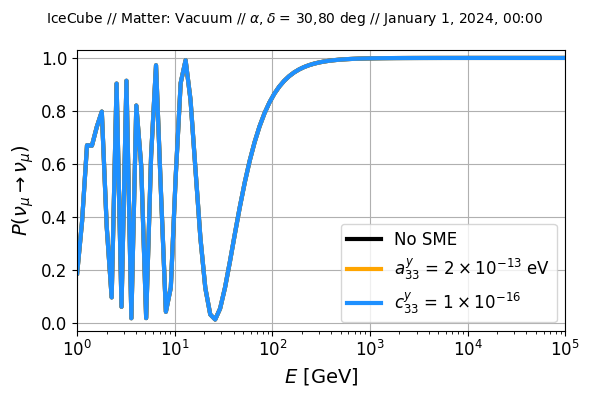

In [32]:

# Initialize oscillation calculators for IceCube and off-axis detectors
calculator = OscCalculator(solver=solver, atmospheric=True, **kw)

# Set matter effects and detectors
calculator.set_matter(matter)
calculator.set_detector(detector)



# Create the figure and axis objects
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle(fr"{detector} // Matter: {matter.title()} // $\alpha,\delta$ = {int(ra_deg)},{int(dec_deg)} deg // {time}", fontsize=10)

print(cases)
# Loop over cases
for case_label, case in cases.items() :

    # Calculate oscillation probabilities
    sme_kw = {"std_osc":True} if case["sme_params"] is None else {"std_osc":False, "sme_params":case["sme_params"]}
    osc_probs, coszen_values, azimuth_values = calculator.calc_osc_prob_sme_directional_atmospheric(
        initial_flavor=initial_flavor,
        nubar=nubar,
        energy_GeV=E_values_GeV,
        ra_rad=np.deg2rad(ra_deg),
        dec_rad=np.deg2rad(dec_deg),
        time=time,
        **sme_kw
    )

    # Plot osc probs
    ax.plot(E_values_GeV, osc_probs[:,final_flavor], color=case["color"], label=case_label, lw=3)

# Format plot
ax.set_xlabel(ENERGY_LABEL, fontsize=14)
ax.set_xscale("log")
ax.set_xlim(E_values_GeV[0], E_values_GeV[-1])
ax.set_ylabel(r"$%s$"%calculator.get_transition_prob_tex(initial_flavor, final_flavor, nubar), fontsize=14)
ax.set_ylim(-0.03, 1.03)
ax.tick_params(labelsize=12)
ax.grid(True)
ax.legend(fontsize=12, loc="lower right")
fig.tight_layout()


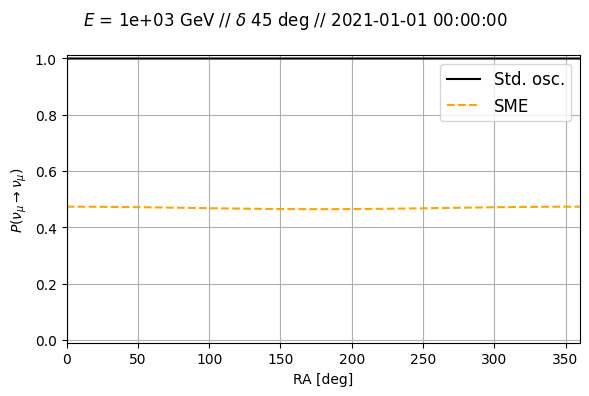

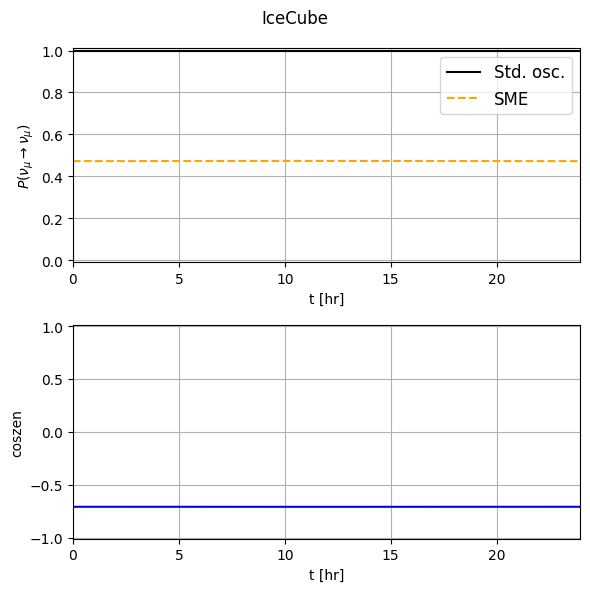

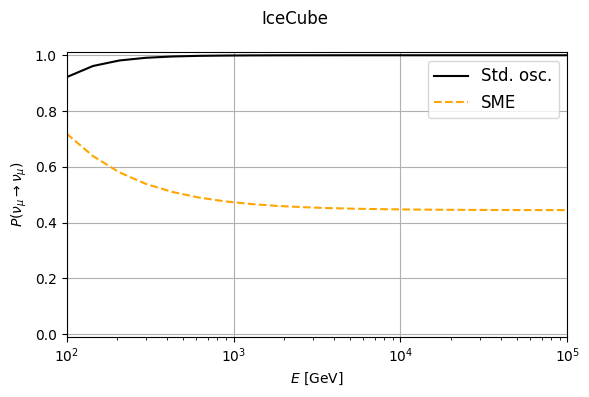

In [34]:
'''
Plo neutrino oscillations with sidereal SME parameters activated

Tom Stuttard
'''

import sys, os, collections, datetime
from astropy.time import Time

from deimos.wrapper.osc_calculator import *
from deimos.utils.constants import SIDEREAL_DAY_hr
from deimos.utils.plotting import *

from deimos.models.liv.sme import get_sme_state_matrix



#
# Steering
#

# import argparse
# parser = argparse.ArgumentParser()
# parser.add_argument("-s", "--solver", type=str, required=False, default="deimos", help="Solver name")
# parser.add_argument("-n", "--num-points", type=int, required=False, default=10, help="Num scan point")
# parser.add_argument("-d", "--detector", type=str, required=False, default="IceCube", help="Detector name (ussed for latitude/longitude)")
# args = parser.parse_args()
num_points=20
solver='nusquids'
detector = 'IceCube'

#
# Define basic system
#

initial_flavor, final_flavor, nubar = 1, 1, False # numu survival

ref_E_GeV = 1e3
ref_time = datetime.datetime(2021, 1, 1, 0, 0, 0, 0) # Midnight, Jan 1st 2021
ref_ra_deg, ref_dec_deg = 30., 45. 

E_GeV_scan = np.geomspace(1e2, 1e5, num=num_points)


#
# Create model
#

# For nuSQuIDS case, need to specify energy nodes covering full space
kw = {}
if solver == "nusquids" :
    kw["energy_nodes_GeV"] = E_GeV_scan
    kw["nusquids_variant"] = "sme"

# Create calculator
calculator = OscCalculator(
    solver=solver,
    atmospheric=True,
    **kw
)

# Use vacuum
calculator.set_matter("vacuum")

# Define detector position
calculator.set_detector(detector)



#
# Define physics cases
#

cases = collections.OrderedDict()

a_magnitude_eV = 1e-13 # Overall strength of a component

# Defining SME operators in mass basis, with a single non-zero element (33)
sme_basis = "mass"
a_eV = get_sme_state_matrix(p33=1e-13)

# Also need to choose a direction for the LIV field
sme_params = {
    "basis" : sme_basis,
    "a_x_eV" : a_eV, # x dir
    # "a_y_eV" : a_eV, # y dir
    # "a_z_eV" : a_eV, # z dir
}

#
# Plot oscillations vs RA
#

# Define neutrino
ra_deg_values = np.linspace(0., 360., num=num_points) # Scan
dec_deg = ref_dec_deg
dec_deg_values = np.full_like(ra_deg_values, dec_deg)
time = ref_time
E_GeV = ref_E_GeV

# Units
ra_rad_values = np.deg2rad(ra_deg_values)
dec_rad_values = np.deg2rad(dec_deg_values)

# Define common args to osc prob calc
common_calc_kw = {
    "initial_flavor":initial_flavor,
    "nubar" : nubar,
    "energy_GeV" : E_GeV,
    "ra_rad" : ra_rad_values,
    "dec_rad" : dec_rad_values,
    "time" : time,
}

# Get std osc probs
P_std, _, _ = calculator.calc_osc_prob_sme_directional_atmospheric(std_osc=True, **common_calc_kw)

# Get LIV osc probs
P_sme, coszen_values, azimuth_values = calculator.calc_osc_prob_sme_directional_atmospheric(sme_params=sme_params, **common_calc_kw)

# Selected chosen final flavor
P_std = P_std[...,final_flavor]
P_sme = P_sme[...,final_flavor]

# Make fig
fig, ax = plt.subplots( figsize=(6, 4) )

fig.suptitle( r"$E$ = %0.3g GeV // $\delta$ %0.3g deg // %s" % (E_GeV, dec_deg, time), fontsize=12 )

# Plot osc probs
ax.plot(ra_deg_values, P_std, color="black", linestyle="-", label="Std. osc.")
ax.plot(ra_deg_values, P_sme, color="orange", linestyle="--", label="SME")

#TODO add second x axis with coszen 

# Plot steering
P_label = "$%s$" % calculator.get_transition_prob_tex(initial_flavor, final_flavor, nubar)

# Formatting
ax.set_xlabel("RA [deg]")
ax.set_ylabel(P_label)
ax.set_ylim(-0.01, 1.01)
ax.set_xlim(ra_deg_values[0], ra_deg_values[-1])
ax.grid(True)
ax.legend(fontsize=12)
fig.tight_layout()



#
# Plot oscillations vs neutrino direction from detector's perspective, over the course of a day
#

# Define neutrino
ra_deg, dec_deg = ref_ra_deg, ref_dec_deg
E_GeV = ref_E_GeV

# Time scan
hr_values = np.linspace(0., SIDEREAL_DAY_hr, num=48) # One sidereal day
time_values = [ ref_time + datetime.timedelta(hours=hr)  for hr in hr_values ]

# Define common args to osc prob calc
common_calc_kw = {
    "initial_flavor":initial_flavor,
    "nubar" : nubar,
    "energy_GeV" : E_GeV,
    "ra_rad" : np.deg2rad(ra_deg),
    "dec_rad" : np.deg2rad(dec_deg),
    "time" : time_values,
}

# Get std osc probs
P_std, _, _ = calculator.calc_osc_prob_sme_directional_atmospheric(std_osc=True, **common_calc_kw)

# Get LIV osc probs
P_sme, coszen_values, azimuth_values = calculator.calc_osc_prob_sme_directional_atmospheric(sme_params=sme_params, **common_calc_kw)

# Selected chosen final flavor
P_std = P_std[...,final_flavor]
P_sme = P_sme[...,final_flavor]

# Make fig
fig, ax = plt.subplots( nrows=2, figsize=(6, 6) )

fig.suptitle(detector)
# fig.suptitle( r"$E$ = %0.3g GeV // $\delta$ = %0.3g deg // %s" % (args.detector, E_GeV, dec_deg, date), fontsize=12 )  #TODO text box

# Plot osc probs
ax[0].plot(hr_values, P_std, color="black", linestyle="-", label="Std. osc.")
ax[0].plot(hr_values, P_sme, color="orange", linestyle="--", label="SME")

# Plot coszen
ax[1].plot(hr_values, coszen_values, color="blue", linestyle="-")

#TODO add second x axis with coszen 

# Formatting
for this_ax in ax :
    this_ax.set_xlabel("t [hr]")
    this_ax.set_xlim(hr_values[0], hr_values[-1])
    this_ax.grid(True)
ax[0].set_ylabel(P_label)
ax[0].set_ylim(-0.01, 1.01)
ax[0].legend(fontsize=12)
ax[1].set_ylabel( "coszen" )
ax[1].set_ylim(-1.01, 1.01)
fig.tight_layout()



#
# Plot oscillations vs energy
#

# Define neutrino
ra_deg, dec_deg = ref_ra_deg, ref_dec_deg
time = ref_time

# Define common args to osc prob calc
common_calc_kw = {
    "initial_flavor":initial_flavor,
    "nubar" : nubar,
    "energy_GeV" : E_GeV_scan,
    "ra_rad" : np.deg2rad(ra_deg),
    "dec_rad" : np.deg2rad(dec_deg),
    "time" : time,
}

# Get std osc probs
P_std, _, _ = calculator.calc_osc_prob_sme_directional_atmospheric(std_osc=True, **common_calc_kw)

# Get LIV osc probs
P_sme, coszen_values, azimuth_values = calculator.calc_osc_prob_sme_directional_atmospheric(sme_params=sme_params, **common_calc_kw)

# Selected chosen final flavor
P_std = P_std[...,final_flavor]
P_sme = P_sme[...,final_flavor]

# Make fig
fig, ax = plt.subplots( figsize=(6, 4) )

fig.suptitle(detector)
# fig.suptitle( r"$E$ = %0.3g GeV // $\delta$ = %0.3g deg // %s" % (args.detector, E_GeV, dec_deg, date), fontsize=12 )  #TODO text box

# Plot osc probs
ax.plot(E_GeV_scan, P_std, color="black", linestyle="-", label="Std. osc.")
ax.plot(E_GeV_scan, P_sme, color="orange", linestyle="--", label="SME")

# Formatting
ax.set_xlabel(r"$E$ [GeV]")
ax.set_xlim(E_GeV_scan[0], E_GeV_scan[-1])
ax.set_xscale("log")
ax.grid(True)
ax.set_ylabel(P_label)
ax.set_ylim(-0.01, 1.01)
ax.legend(fontsize=12)
fig.tight_layout()


#
# Done
#

# print("")
# dump_figures_to_pdf( __file__.replace(".py",".pdf") )
